In [2]:
import tensorflow_datasets as tfds

ds = tfds.load('quickdraw_bitmap', split='train[:1%]') 

print(ds)
print("Number of examples:", ds.cardinality().numpy())

Dl Completed...: 100%|██████████| 345/345 [00:08<00:00, 39.01 url/s]
                                                                             

Dataset quickdraw_bitmap downloaded and prepared to /home/alexander/tensorflow_datasets/quickdraw_bitmap/3.0.0. Subsequent calls will reuse this data.
<_PrefetchDataset element_spec={'image': TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>
Number of examples: 504263


In [1]:
import os
from pathlib import Path

import numpy as np
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

In [3]:
data_dir = Path("/home/alexander/tensorflow_datasets")

ds_train, info = tfds.load(
    "quickdraw_bitmap",
    split="train",
    data_dir=str(data_dir),
    with_info=True,
    shuffle_files=False,
)

class_names = info.features["label"].names
print("Number of classes:", len(class_names))
print("Number of examples:", info.splits["train"].num_examples)

Number of classes: 345
Number of examples: 50426266


In [4]:
print("Class names sample:", class_names[:10])

for split_name in info.splits:
    print(split_name, info.splits[split_name].num_examples)

sample = next(iter(ds_train))
print("Image shape:", sample["image"].shape)
print("Image dtype:", sample["image"].dtype)
print("Image min/max:", int(tfds.as_numpy(sample["image"]).min()), int(tfds.as_numpy(sample["image"]).max()))
print("Label:", int(tfds.as_numpy(sample["label"])))

Class names sample: ['aircraft carrier', 'airplane', 'alarm clock', 'ambulance', 'angel', 'animal migration', 'ant', 'anvil', 'apple', 'arm']
train 50426266


I0000 00:00:1780291008.719519   10321 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Image shape: (28, 28, 1)
Image dtype: <dtype: 'uint8'>
Image min/max: 0 255
Label: 12


In [5]:
n_samples = 60000

X = []
y = []

for ex in tfds.as_numpy(ds_train.take(n_samples)):
    X.append(ex["image"])
    y.append(ex["label"])

X = np.stack(X)
y = np.array(y, dtype=np.int64)

print("X shape:", X.shape)
print("X dtype:", X.dtype)
print("X min/max:", X.min(), X.max())
print("y shape:", y.shape)
print("Unique labels:", len(np.unique(y)))
print("class_names:", len(class_names))

X shape: (60000, 28, 28, 1)
X dtype: uint8
X min/max: 0 255
y shape: (60000,)
Unique labels: 345
class_names: 345


In [6]:
assert y.ndim == 1
assert len(np.unique(y)) <= len(class_names)

print("y shape OK:", y.shape)
print("Unique labels:", len(np.unique(y)))
print("class_names:", len(class_names))

y shape OK: (60000,)
Unique labels: 345
class_names: 345


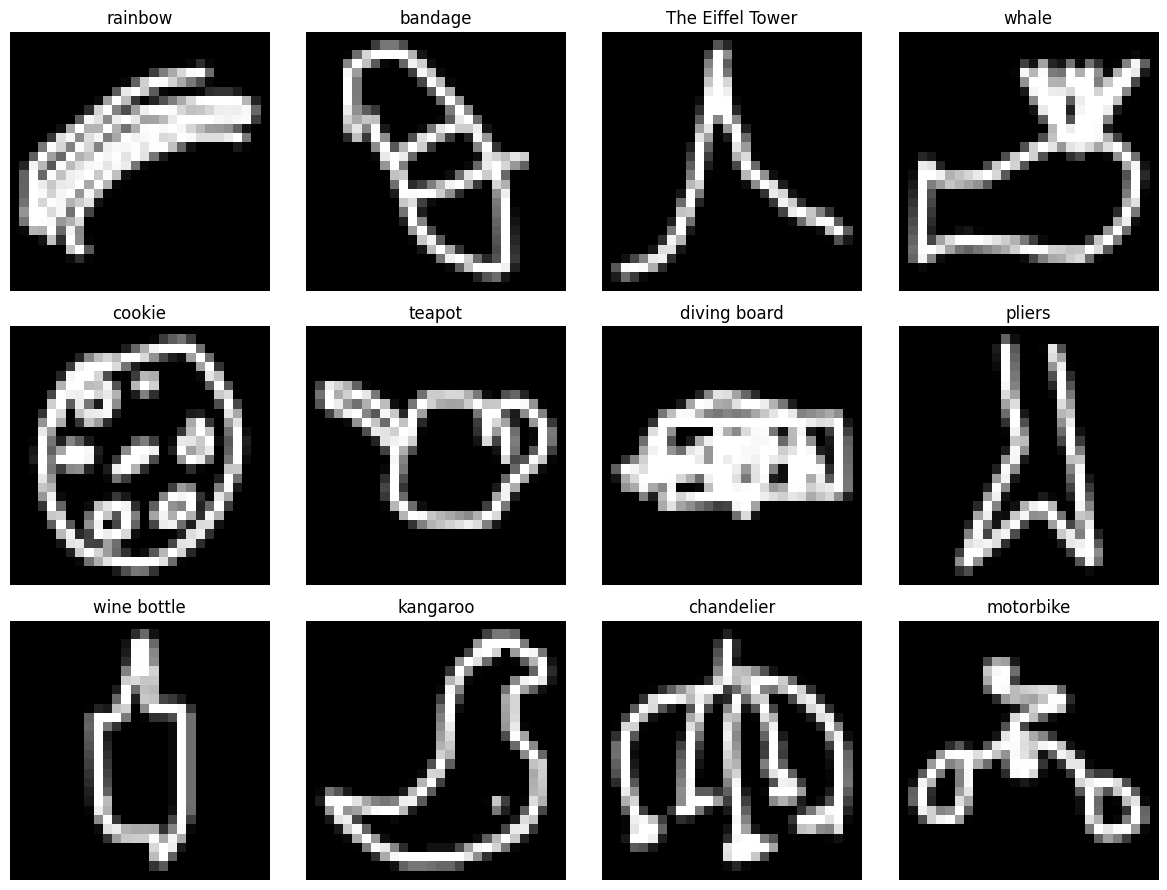

In [7]:
idxs = np.random.choice(len(X), size=12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.ravel()

for ax, idx in zip(axes, idxs):
    ax.imshow(X[idx].squeeze(), cmap="gray")
    ax.set_title(class_names[y[idx]])
    ax.axis("off")

plt.tight_layout()
plt.show()

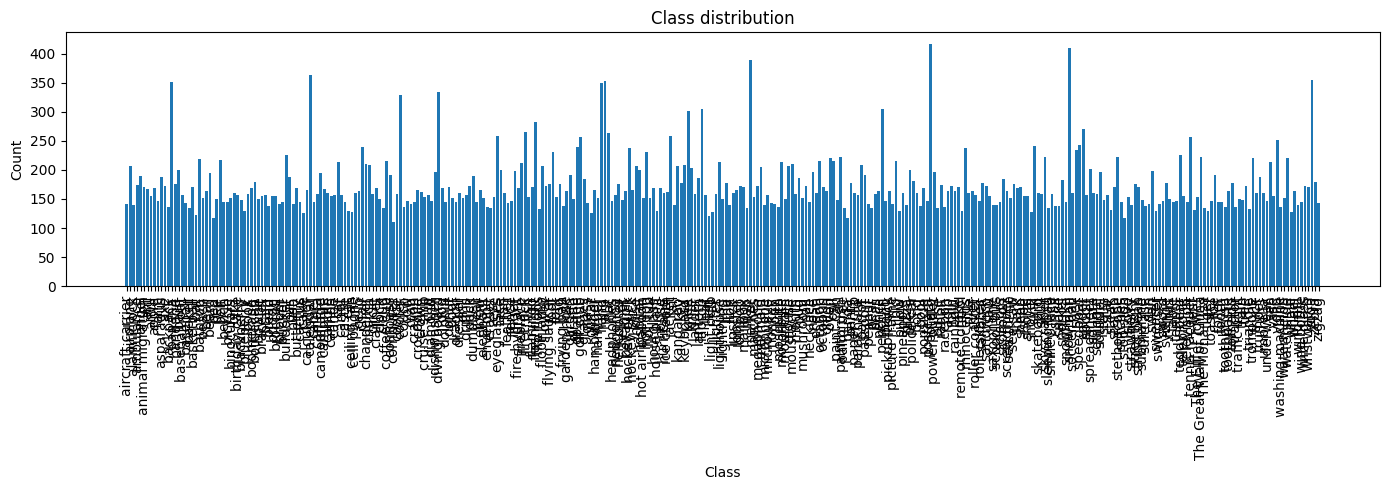

In [8]:
counts = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar([class_names[i] for i in counts.index], counts.values)
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class distribution")
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def preprocess_images(X):
    X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
    X_tf = tf.image.resize(X_tf, (32, 32), method="bilinear")
    X_tf = X_tf / 255.0
    return X_tf.numpy().astype(np.float32)

X_proc = preprocess_images(X)

print("X_proc:", X_proc.shape, X_proc.dtype, X_proc.min(), X_proc.max())    

W0000 00:00:1780291061.280209    9591 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.
W0000 00:00:1780291061.423253    9591 cpu_allocator_impl.cc:82] Allocation of 245760000 exceeds 10% of free system memory.


X_proc: (60000, 32, 32, 1) float32 0.0 1.0


In [11]:
np.random.seed(0)
perm1 = np.random.permutation(len(X_proc))
split1 = int(0.8 * len(X_proc))

# Разделим на тренировочную и валидационную выборки
X_train, y_train = X_proc[perm1[:split1]], y[perm1[:split1]]
X_temp,   y_temp   = X_proc[perm1[split1:]], y[perm1[split1:]]

perm2 = np.random.permutation(len(X_temp))
split2 = int(0.5 * len(X_temp))

X_val, y_val = X_temp[perm2[:split2]], y_temp[perm2[:split2]]
X_test,   y_test   = X_temp[perm2[split2:]], y_temp[perm2[split2:]]


print("X_train:", X_train.shape, y_train.shape)
print("X_val:", X_val.shape, y_val.shape)
print("X_test:", X_test.shape, y_test.shape)

print("unique train labels:", len(np.unique(y_train)))
print("unique val labels:", len(np.unique(y_val)))
print("unique test labels:", len(np.unique(y_test)))
print("class_names:", len(class_names))

X_train: (48000, 32, 32, 1) (48000,)
X_val: (6000, 32, 32, 1) (6000,)
X_test: (6000, 32, 32, 1) (6000,)
unique train labels: 345
unique val labels: 345
unique test labels: 345
class_names: 345


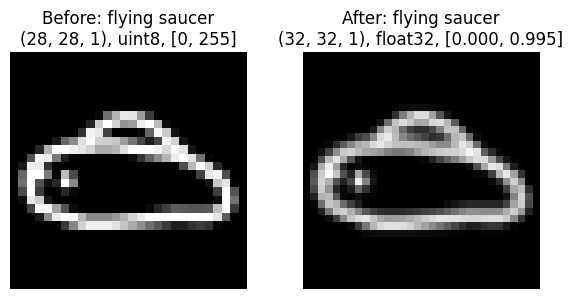

In [12]:
import random

idx = random.randint(0, n_samples - 1)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(X[idx].squeeze(), cmap="gray")
axes[0].set_title(f"Before: {class_names[y[idx]]}\n{X[idx].shape}, {X[idx].dtype}, [{X[idx].min()}, {X[idx].max()}]")
axes[0].axis("off")

axes[1].imshow(X_proc[idx].squeeze(), cmap="gray")
axes[1].set_title(f"After: {class_names[y[idx]]}\n{X_proc[idx].shape}, {X_proc[idx].dtype}, [{X_proc[idx].min():.3f}, {X_proc[idx].max():.3f}]")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [13]:
assert X_train.shape[1:] == (32, 32, 1)
assert X_val.shape[1:] == (32, 32, 1)
assert X_test.shape[1:] == (32, 32, 1)

assert X_train.dtype == np.float32
assert X_val.dtype == np.float32
assert X_test.dtype == np.float32

assert 0.0 <= X_train.min() and X_train.max() <= 1.0
assert 0.0 <= X_val.min() and X_val.max() <= 1.0
assert 0.0 <= X_test.min() and X_test.max() <= 1.0

assert y_train.ndim == 1 and y_val.ndim == 1 and y_test.ndim == 1

In [27]:
import time
import pickle
import numpy as np
import copy

class MLP:
    def __init__(
        self,
        layer_sizes,
        activation="relu",
        lr=0.001,
        l2=0.0,
        l1=0.0,
        dropout=0.0,
        optimizer="adam",
        init="he",
        seed=42,
    ):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.lr = lr
        self.l2 = l2
        self.l1 = l1
        self.dropout = dropout
        self.optimizer = optimizer
        self.init = init
        self.rng = np.random.default_rng(seed)

        self.W, self.b = [], []
        self.Z_list, self.A_list = [], []
        self.dW_list, self.db_list = [], []
        self.masks = [None] * (len(layer_sizes) - 2)

        for i in range(len(layer_sizes) - 1):
            in_dim, out_dim = layer_sizes[i], layer_sizes[i + 1]
            self.W.append(self._init_weight(in_dim, out_dim))
            self.b.append(np.zeros((1, out_dim), dtype=np.float32))

        self.m_w = [np.zeros_like(w) for w in self.W]
        self.v_w = [np.zeros_like(w) for w in self.W]
        self.m_b = [np.zeros_like(b) for b in self.b]
        self.v_b = [np.zeros_like(b) for b in self.b]
        self.t = 0

    def _init_weight(self, in_dim, out_dim):
        if self.init == "xavier":
            limit = np.sqrt(6.0 / (in_dim + out_dim))
            return self.rng.uniform(-limit, limit, size=(in_dim, out_dim)).astype(np.float32)
        if self.init == "he":
            return (self.rng.standard_normal((in_dim, out_dim)) * np.sqrt(2.0 / in_dim)).astype(np.float32)
        return (self.rng.standard_normal((in_dim, out_dim)) * 0.01).astype(np.float32)

    def _activate(self, Z):
        if self.activation == "sigmoid":
            return 1 / (1 + np.exp(-Z))
        elif self.activation == "relu":
            return np.maximum(0, Z)
        elif self.activation == "tanh":
            return np.tanh(Z)
        else:
            raise ValueError(self.activation)

    def _dactivate(self, Z):
        if self.activation == "sigmoid":
            s = 1 / (1 + np.exp(-Z))
            return s * (1 - s)
        elif self.activation == "relu":
            return (Z > 0).astype(np.float32)
        elif self.activation == "tanh":
            return 1 - np.tanh(Z) ** 2
        else:
            raise ValueError(self.activation)

    def forward(self, X, train=True):
        self.Z_list, self.A_list = [], []
        A = X.astype(np.float32)
        self.A_list.append(A)

        for i in range(len(self.W)):
            Z = A.dot(self.W[i]) + self.b[i]
            self.Z_list.append(Z)

            if i < len(self.W) - 1:
                A = self._activate(Z)
                if train and self.dropout > 0:
                    mask = (self.rng.random(A.shape) > self.dropout).astype(np.float32) / (1.0 - self.dropout)
                    A *= mask
                    self.masks[i] = mask
            else:
                A = Z

            self.A_list.append(A)

        return A

    def softmax(self, logits):
        logits = logits - np.max(logits, axis=1, keepdims=True)
        exp = np.exp(logits)
        return exp / np.sum(exp, axis=1, keepdims=True)

    def softmax_cross_entropy(self, logits, y):
        probs = self.softmax(logits)
        n = y.shape[0]
        loss = -np.mean(np.log(probs[np.arange(n), y] + 1e-12))

        loss += (self.l2 / 2.0) * sum(np.sum(W * W) for W in self.W)
        loss += self.l1 * sum(np.sum(np.abs(W)) for W in self.W)
        return loss, probs

    def backward(self, y_true):
        m = y_true.shape[0]
        L = len(self.W)
        
        logits = self.A_list[-1]
        probs = self.softmax(logits)
        
        delta = probs.copy()
        delta[np.arange(m), y_true] -= 1.0
        delta /= m
        
        self.dW_list, self.db_list = [None] * L, [None] * L
        
        a_prev = self.A_list[-2]
        self.dW_list[L-1] = a_prev.T.dot(delta) + self.l2 * self.W[L-1] + self.l1 * np.sign(self.W[L-1])
        self.db_list[L-1] = np.sum(delta, axis=0, keepdims=True)
        
        for l in range(L - 2, -1, -1):
            z = self.Z_list[l]
            a_prev = self.A_list[l]
            
            delta = delta.dot(self.W[l + 1].T) * self._dactivate(z)
            
            if self.dropout > 0 and self.masks[l] is not None:
                delta *= self.masks[l]
                
            self.dW_list[l] = a_prev.T.dot(delta) + self.l2 * self.W[l] + self.l1 * np.sign(self.W[l])
            self.db_list[l] = np.sum(delta, axis=0, keepdims=True)
        
    def step_sgd(self):
        for i in range(len(self.W)):
            self.W[i] -= self.lr * self.dW_list[i]
            self.b[i] -= self.lr * self.db_list[i]

    def step_adam(self, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for i in range(len(self.W)):
            self.m_w[i] = beta1 * self.m_w[i] + (1 - beta1) * self.dW_list[i]
            self.v_w[i] = beta2 * self.v_w[i] + (1 - beta2) * (self.dW_list[i] ** 2)
            self.m_b[i] = beta1 * self.m_b[i] + (1 - beta1) * self.db_list[i]
            self.v_b[i] = beta2 * self.v_b[i] + (1 - beta2) * (self.db_list[i] ** 2)

            m_w_hat = self.m_w[i] / (1 - beta1 ** self.t)
            v_w_hat = self.v_w[i] / (1 - beta2 ** self.t)
            m_b_hat = self.m_b[i] / (1 - beta1 ** self.t)
            v_b_hat = self.v_b[i] / (1 - beta2 ** self.t)

            self.W[i] -= self.lr * m_w_hat / (np.sqrt(v_w_hat) + eps)
            self.b[i] -= self.lr * m_b_hat / (np.sqrt(v_b_hat) + eps)

    def predict(self, X):
        logits = self.forward(X, train=False)
        return np.argmax(logits, axis=1)

    def accuracy(self, X, y):
        pred = self.predict(X)
        return np.mean(pred == y)

    def save(self, path):
        state = {
            "layer_sizes": self.layer_sizes,
            "activation": self.activation,
            "lr": self.lr,
            "l2": self.l2,
            "l1": self.l1,
            "dropout": self.dropout,
            "optimizer": self.optimizer,
            "init": self.init,
            "W": self.W,
            "b": self.b,
            "m_w": self.m_w,
            "v_w": self.v_w,
            "m_b": self.m_b,
            "v_b": self.v_b,
            "t": self.t,
        }
        with open(path, "wb") as f:
            pickle.dump(state, f)

    @classmethod
    def load(cls, path):
        with open(path, "rb") as f:
            state = pickle.load(f)

        model = cls(
            layer_sizes=state["layer_sizes"],
            activation=state["activation"],
            lr=state["lr"],
            l2=state["l2"],
            l1=state["l1"],
            dropout=state["dropout"],
            optimizer=state["optimizer"],
            init=state["init"],
        )
        model.W = state["W"]
        model.b = state["b"]
        model.m_w = state["m_w"]
        model.v_w = state["v_w"]
        model.m_b = state["m_b"]
        model.v_b = state["v_b"]
        model.t = state["t"]
        return model
    
    def get_state(self):
        return {
            "layer_sizes": self.layer_sizes,
            "activation": self.activation,
            "lr": self.lr,
            "l2": self.l2,
            "l1": self.l1,
            "dropout": self.dropout,
            "optimizer": self.optimizer,
            "init": self.init,
            "W": [w.copy() for w in self.W],
            "b": [b.copy() for b in self.b],
            "m_w": [w.copy() for w in self.m_w],
            "v_w": [w.copy() for w in self.v_w],
            "m_b": [b.copy() for b in self.m_b],
            "v_b": [b.copy() for b in self.v_b],
            "t": self.t,
    }
    
    def set_state(self, state):
        self.layer_sizes = state["layer_sizes"]
        self.activation = state["activation"]
        self.lr = state["lr"]
        self.l2 = state["l2"]
        self.l1 = state["l1"]
        self.dropout = state["dropout"]
        self.optimizer = state["optimizer"]
        self.init = state["init"]

        self.W = [w.copy() for w in state["W"]]
        self.b = [b.copy() for b in state["b"]]
        self.m_w = [w.copy() for w in state["m_w"]]
        self.v_w = [w.copy() for w in state["v_w"]]
        self.m_b = [b.copy() for b in state["m_b"]]
        self.v_b = [b.copy() for b in state["v_b"]]
        self.t = state["t"]

        self.Z_list = []
        self.A_list = []
        self.dW_list = []
        self.db_list = []
        self.masks = [None] * (len(self.layer_sizes) - 2)

In [30]:
import copy

def iterate_minibatches(X, y, batch_size=64, shuffle=True, seed=42):
    idx = np.arange(len(X))
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(idx)
    for start in range(0, len(X), batch_size):
        batch_idx = idx[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]

def evaluate(model, X, y):
    logits = model.forward(X, train=False)
    loss, _ = model.softmax_cross_entropy(logits, y)
    acc = model.accuracy(X, y)
    return loss, acc

def train_model(
    model,
    X_train,
    y_train,
    X_val, y_val, 
    epochs=50, 
    batch_size=64, 
    optimizer="adam",
    patience=5,
    min_delta=1e-4,
    save_path="best_numpymlp.pt",
):
    history = []
    best_val_acc = -float("inf")
    best_state = None
    best_epoch = 0
    bad_epochs = 0
    
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_losses = []

        for Xb, yb in iterate_minibatches(X_train, y_train, batch_size=batch_size, shuffle=True, seed=42 + epoch):
            logits = model.forward(Xb, train=True)
            loss, _ = model.softmax_cross_entropy(logits, yb)
            model.backward(yb)

            if optimizer == "sgd":
                model.step_sgd()
            else:
                model.step_adam()

            train_losses.append(loss)
        
        train_loss, train_acc = evaluate(model, X_train, y_train)
        val_loss, val_acc = evaluate(model, X_val, y_val)
        epoch_time = time.time() - t0
        train_loss = float(np.mean(train_losses))
        
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "time_sec": epoch_time,
        })

        print(f"epoch={epoch:03d} train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f} time={epoch_time:.1f}s")
        
        if val_acc > best_val_acc + min_delta:
            best_val_acc = val_acc
            best_epoch = epoch
            bad_epochs = 0
            best_state = copy.deepcopy(model.get_state())
            model.save(save_path)
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}, best val_acc={best_val_acc:.4f}")
            break

    if best_state is not None:
        model.set_state(best_state)

    return pd.DataFrame(history)

In [31]:
X_train_flat = X_train.reshape(len(X_train), -1).astype(np.float32)
X_val_flat = X_val.reshape(len(X_val), -1).astype(np.float32)
X_test_flat = X_test.reshape(len(X_test), -1).astype(np.float32)

print(X_train_flat.shape)
print(X_val_flat.shape)
print(X_test_flat.shape)

(48000, 1024)
(6000, 1024)
(6000, 1024)


In [32]:
input_dim = 32 * 32
output_dim = len(class_names)

model = MLP(
    layer_sizes=[input_dim, 256, 128, output_dim],
    activation="relu",
    lr=1e-3,
    l2=1e-4,
    l1=0.0,
    dropout=0.1,
    optimizer="adam",
    init="xavier",
    seed=42,
)

history_mlp = train_model(
    model,
    X_train_flat, y_train,
    X_val_flat, y_val,
    epochs=50,
    batch_size=64,
    optimizer="adam",
)

epoch=001 train_loss=4.8196 val_loss=4.1771 val_acc=0.1677 time=23.5s
epoch=002 train_loss=4.0063 val_loss=3.8954 val_acc=0.2138 time=36.3s
epoch=003 train_loss=3.7210 val_loss=3.7319 val_acc=0.2377 time=22.2s
epoch=004 train_loss=3.5190 val_loss=3.6288 val_acc=0.2560 time=18.8s
epoch=005 train_loss=3.3775 val_loss=3.5538 val_acc=0.2705 time=28.7s
epoch=006 train_loss=3.2561 val_loss=3.5170 val_acc=0.2820 time=26.0s
epoch=007 train_loss=3.1773 val_loss=3.4935 val_acc=0.2878 time=29.4s
epoch=008 train_loss=3.0937 val_loss=3.4696 val_acc=0.2965 time=37.6s
epoch=009 train_loss=3.0260 val_loss=3.4616 val_acc=0.2962 time=27.4s
epoch=010 train_loss=2.9710 val_loss=3.4809 val_acc=0.3007 time=32.0s
epoch=011 train_loss=2.9252 val_loss=3.4672 val_acc=0.3002 time=32.5s
epoch=012 train_loss=2.8787 val_loss=3.4567 val_acc=0.3047 time=41.1s
epoch=013 train_loss=2.8352 val_loss=3.5150 val_acc=0.2960 time=30.3s
epoch=014 train_loss=2.8011 val_loss=3.4755 val_acc=0.3070 time=50.5s
epoch=015 train_loss

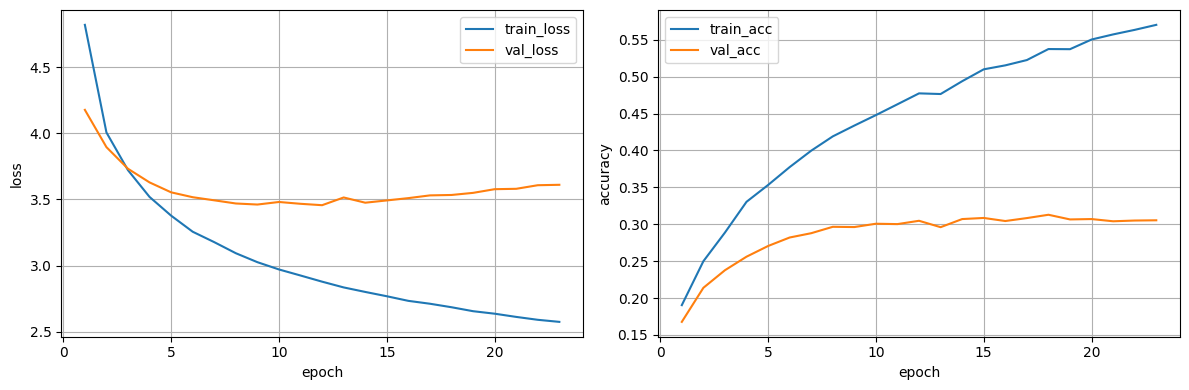

test_loss: 3.5643423
test_acc: 0.30783333333333335
loaded test acc: 0.30783333333333335


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_mlp["epoch"], history_mlp["train_loss"], label="train_loss")
axes[0].plot(history_mlp["epoch"], history_mlp["val_loss"], label="val_loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history_mlp["epoch"], history_mlp["train_acc"], label="train_acc")
axes[1].plot(history_mlp["epoch"], history_mlp["val_acc"], label="val_acc")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

test_loss, test_acc = evaluate(model, X_test_flat, y_test)
print("test_loss:", test_loss)
print("test_acc:", test_acc)

model.save("quickdraw_mlp.pkl")
loaded_model = MLP.load("quickdraw_mlp.pkl")
print("loaded test acc:", loaded_model.accuracy(X_test_flat, y_test))

In [34]:
model = MLP(
    layer_sizes=[input_dim, 256, 128, output_dim],
    activation="tanh",
    lr=1e-3,
    l2=1e-4,
    l1=0.0,
    dropout=0.1,
    optimizer="adam",
    init="xavier",
    seed=42,
)

history_mlp_tanh = train_model(
    model,
    X_train_flat, y_train,
    X_val_flat, y_val,
    epochs=50,
    batch_size=64,
    optimizer="adam",
)

epoch=001 train_loss=4.7986 val_loss=4.3105 val_acc=0.1600 time=27.0s
epoch=002 train_loss=4.1154 val_loss=4.0126 val_acc=0.2065 time=37.6s
epoch=003 train_loss=3.8427 val_loss=3.8708 val_acc=0.2263 time=30.1s
epoch=004 train_loss=3.6690 val_loss=3.7673 val_acc=0.2403 time=30.3s
epoch=005 train_loss=3.5456 val_loss=3.6878 val_acc=0.2537 time=29.3s
epoch=006 train_loss=3.4482 val_loss=3.6602 val_acc=0.2593 time=27.5s
epoch=007 train_loss=3.3688 val_loss=3.6129 val_acc=0.2703 time=25.6s
epoch=008 train_loss=3.2999 val_loss=3.6020 val_acc=0.2733 time=29.2s
epoch=009 train_loss=3.2426 val_loss=3.5898 val_acc=0.2818 time=32.5s
epoch=010 train_loss=3.1866 val_loss=3.5827 val_acc=0.2810 time=30.1s
epoch=011 train_loss=3.1407 val_loss=3.5792 val_acc=0.2840 time=33.7s
epoch=012 train_loss=3.1017 val_loss=3.5887 val_acc=0.2835 time=31.2s
epoch=013 train_loss=3.0637 val_loss=3.5794 val_acc=0.2845 time=32.8s
epoch=014 train_loss=3.0293 val_loss=3.5874 val_acc=0.2858 time=34.1s
epoch=015 train_loss

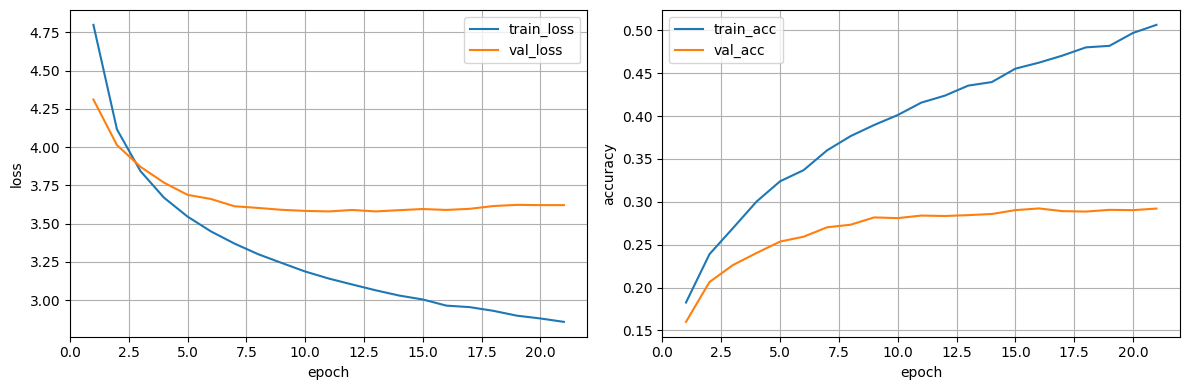

test_loss: 3.6401753
test_acc: 0.2826666666666667
loaded test acc: 0.2826666666666667


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_mlp_tanh["epoch"], history_mlp_tanh["train_loss"], label="train_loss")
axes[0].plot(history_mlp_tanh["epoch"], history_mlp_tanh["val_loss"], label="val_loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history_mlp_tanh["epoch"], history_mlp_tanh["train_acc"], label="train_acc")
axes[1].plot(history_mlp_tanh["epoch"], history_mlp_tanh["val_acc"], label="val_acc")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

test_loss, test_acc = evaluate(model, X_test_flat, y_test)
print("test_loss:", test_loss)
print("test_acc:", test_acc)

model.save("quickdraw_mlp_tanh.pkl")
loaded_model = MLP.load("quickdraw_mlp_tanh.pkl")
print("loaded test acc:", loaded_model.accuracy(X_test_flat, y_test))

In [37]:
import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import Dataset, DataLoader

import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import Dataset, DataLoader

class TorchMLP(nn.Module):
    def __init__(self, in_dim=1024, hidden_sizes=(256, 128), out_dim=345, dropout_p=0.5, activation="relu"):
        super().__init__()
        self.flatten = nn.Flatten()
        self.activation = activation
        
        layers = []
        prev_dim = in_dim
        for idx, h in enumerate(hidden_sizes):
            layers.append(nn.Linear(prev_dim, h))
            if self.activation == "relu":
                layers.append(nn.ReLU())
            elif self.activation == "tanh":
                layers.append(nn.Tanh())
            if idx == 0:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.Dropout(dropout_p))
            prev_dim = h

        self.hidden = nn.Sequential(*layers)
        self.output = nn.Linear(prev_dim, out_dim)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.xavier_uniform_(m.weight)
                init.zeros_(m.bias)

    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = self.output(x)
        return x    
    
class QDDataset(Dataset):
    def __init__(self, data, targets):
        self.data = torch.as_tensor(data, dtype=torch.float32)
        self.targets = torch.as_tensor(targets, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        y = self.targets[idx]
        
        if x.ndim == 3 and x.shape[-1] == 1:
            x = x.permute(2, 0, 1)   # (H, W, 1) -> (1, H, W)
        
        return x, y    
    
train_data = QDDataset(X_train, y_train)
val_data = QDDataset(X_val, y_val)
test_data = QDDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)
    
model = TorchMLP()
    
images, labels = next(iter(train_loader))
outputs = model(images)
    
print("Output shape: ", outputs.shape)
print("Batch labels shape: ", labels.shape)
print("Number of hidden layers: ", len(model.hidden))
    
    
    


Output shape:  torch.Size([64, 345])
Batch labels shape:  torch.Size([64])
Number of hidden layers:  7


epoch=001 train_loss=4.5999 train_acc=0.1067 val_loss=3.9706 val_acc=0.1898 time=6.3s
epoch=002 train_loss=3.8144 train_acc=0.1995 val_loss=3.7031 val_acc=0.2215 time=6.5s
epoch=003 train_loss=3.5400 train_acc=0.2372 val_loss=3.5474 val_acc=0.2565 time=7.1s
epoch=004 train_loss=3.3589 train_acc=0.2659 val_loss=3.4324 val_acc=0.2668 time=4.2s
epoch=005 train_loss=3.2263 train_acc=0.2863 val_loss=3.3769 val_acc=0.2832 time=3.8s
epoch=006 train_loss=3.1179 train_acc=0.3003 val_loss=3.3797 val_acc=0.2800 time=3.7s
epoch=007 train_loss=3.0345 train_acc=0.3144 val_loss=3.3604 val_acc=0.2920 time=3.7s
epoch=008 train_loss=2.9582 train_acc=0.3245 val_loss=3.3343 val_acc=0.2878 time=3.9s
epoch=009 train_loss=2.8851 train_acc=0.3377 val_loss=3.3411 val_acc=0.2988 time=4.2s
epoch=010 train_loss=2.8271 train_acc=0.3461 val_loss=3.3196 val_acc=0.3040 time=5.5s
epoch=011 train_loss=2.7670 train_acc=0.3544 val_loss=3.3538 val_acc=0.3015 time=5.9s
epoch=012 train_loss=2.7179 train_acc=0.3618 val_loss=

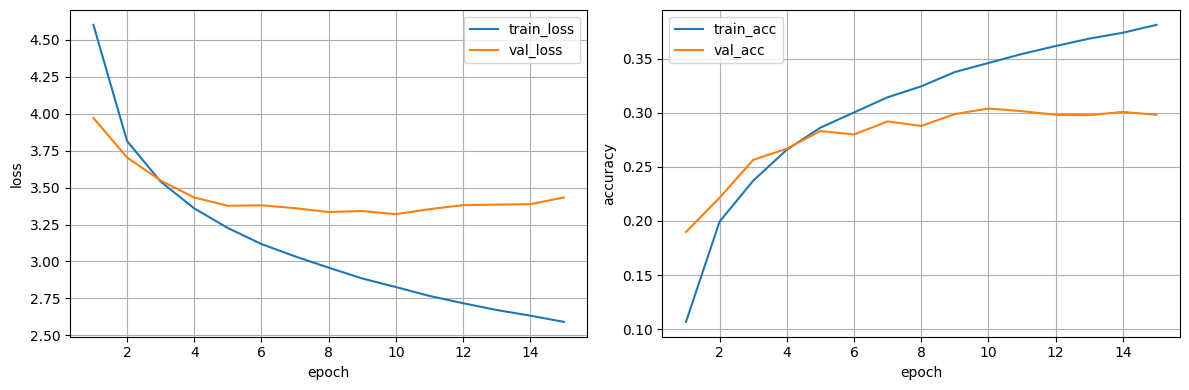

test_loss=3.3800 test_acc=0.2935


In [38]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import copy


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TorchMLP(
    in_dim=32 * 32,
    hidden_sizes=(256, 128),
    out_dim=len(class_names),
    dropout_p=0.1
).to(device)

counts = np.bincount(y_train, minlength=len(class_names))
class_weights = counts.sum() / (len(class_names) * np.maximum(counts, 1))
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights)  # если class_weights уже посчитаны
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)


def run_epoch(model, loader, criterion, optimizer=None, train=False, device="cpu"):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if train:
                loss.backward()
                optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += bs

    return total_loss / total, correct / total


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50,
    patience=5,
    min_delta=1e-4,
    save_path="best_torchmlp.pt",
):
    history = []
    best_val_acc = -float("inf")
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_loss, train_acc = run_epoch(
            model, train_loader, criterion, optimizer=optimizer, train=True, device=device
        )
        val_loss, val_acc = run_epoch(
            model, val_loader, criterion, optimizer=None, train=False, device=device
        )

        epoch_time = time.time() - t0

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "time_sec": epoch_time,
        })

        print(
            f"epoch={epoch:03d} "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
            f"time={epoch_time:.1f}s"
        )

        if val_acc > best_val_acc + min_delta:
            best_val_acc = val_acc
            best_epoch = epoch
            bad_epochs = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save({
                "model_state_dict": best_state,
                "epoch": epoch,
                "val_acc": val_acc,
            }, save_path)
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}, best val_acc={best_val_acc:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return pd.DataFrame(history), best_epoch, best_val_acc

history_torch, best_epoch, best_val_acc = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=50,
    patience=5,
    min_delta=1e-4,
    save_path="best_torchmlp.pt",
)

print("best_epoch:", best_epoch)
print("best_val_acc:", best_val_acc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_torch["epoch"], history_torch["train_loss"], label="train_loss")
axes[0].plot(history_torch["epoch"], history_torch["val_loss"], label="val_loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history_torch["epoch"], history_torch["train_acc"], label="train_acc")
axes[1].plot(history_torch["epoch"], history_torch["val_acc"], label="val_acc")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer=None, train=False, device=device)
print(f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}")

epoch=001 train_loss=4.5424 train_acc=0.1258 val_loss=4.0649 val_acc=0.1812 time=5.7s
epoch=002 train_loss=3.8019 train_acc=0.2192 val_loss=3.7713 val_acc=0.2220 time=5.9s
epoch=003 train_loss=3.4832 train_acc=0.2628 val_loss=3.6194 val_acc=0.2438 time=4.0s
epoch=004 train_loss=3.2400 train_acc=0.2989 val_loss=3.5100 val_acc=0.2622 time=3.4s
epoch=005 train_loss=3.0471 train_acc=0.3275 val_loss=3.4670 val_acc=0.2728 time=3.6s
epoch=006 train_loss=2.8818 train_acc=0.3556 val_loss=3.4543 val_acc=0.2717 time=3.5s
epoch=007 train_loss=2.7396 train_acc=0.3783 val_loss=3.4588 val_acc=0.2735 time=3.5s
epoch=008 train_loss=2.6086 train_acc=0.4041 val_loss=3.4587 val_acc=0.2717 time=3.9s
epoch=009 train_loss=2.4974 train_acc=0.4212 val_loss=3.4912 val_acc=0.2727 time=5.8s
epoch=010 train_loss=2.3936 train_acc=0.4383 val_loss=3.5272 val_acc=0.2687 time=5.8s
epoch=011 train_loss=2.2954 train_acc=0.4578 val_loss=3.5690 val_acc=0.2667 time=5.6s
epoch=012 train_loss=2.2123 train_acc=0.4722 val_loss=

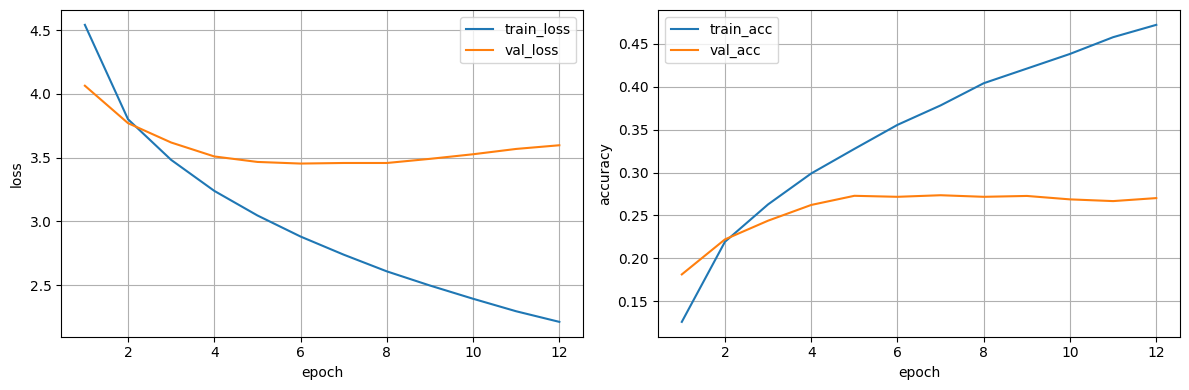

test_loss=3.5255 test_acc=0.2708


In [41]:

model = TorchMLP(
    in_dim=32 * 32,
    hidden_sizes=(256, 128),
    out_dim=len(class_names),
    dropout_p=0.0,
    activation="tanh"
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)  # если class_weights уже посчитаны
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

history_torch_tanh, best_epoch, best_val_acc = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=50,
    patience=5,
    min_delta=1e-4,
    save_path="best_torchmlp_tanh.pt",
)

print("best_epoch:", best_epoch)
print("best_val_acc:", best_val_acc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_torch_tanh["epoch"], history_torch_tanh["train_loss"], label="train_loss")
axes[0].plot(history_torch_tanh["epoch"], history_torch_tanh["val_loss"], label="val_loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history_torch_tanh["epoch"], history_torch_tanh["train_acc"], label="train_acc")
axes[1].plot(history_torch_tanh["epoch"], history_torch_tanh["val_acc"], label="val_acc")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer=None, train=False, device=device)
print(f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}")


In [42]:
import copy
import time
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

class TorchCNN(nn.Module):
    def __init__(self, num_classes, dropout_p=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(256, num_classes),
        )

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        if x.ndim == 3:
            x = x.unsqueeze(1)
        return self.classifier(self.features(x))

In [43]:
def run_epoch(model, loader, criterion, optimizer=None, train=False, device="cpu"):
    model.train(train)
    total_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if train:
                loss.backward()
                optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += bs

    return total_loss / total, correct / total


def train_cnn(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    patience=5,
    min_delta=1e-4,
    save_path="best_cnn.pt",
):
    history = []
    best_val_acc = -float("inf")
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer=optimizer, train=True, device=device)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None, train=False, device=device)

        dt = time.time() - t0
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "time_sec": dt,
        })

        print(
            f"epoch={epoch:03d} "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
            f"time={dt:.1f}s"
        )

        if val_acc > best_val_acc + min_delta:
            best_val_acc = val_acc
            best_epoch = epoch
            bad_epochs = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save({
                "model_state_dict": best_state,
                "epoch": epoch,
                "val_acc": val_acc,
            }, save_path)
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}, best val_acc={best_val_acc:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return pd.DataFrame(history), best_epoch, best_val_acc

In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TorchCNN(num_classes=len(class_names), dropout_p=0.25).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)  # если веса классов у вас уже посчитаны
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

history_df, best_epoch, best_val_acc = train_cnn(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=30,
    patience=5,
    save_path="best_cnn.pt",
)

print("best_epoch:", best_epoch)
print("best_val_acc:", best_val_acc)

epoch=001 train_loss=4.5669 train_acc=0.1045 val_loss=3.5050 val_acc=0.2515 time=64.3s
epoch=002 train_loss=3.3487 train_acc=0.2629 val_loss=2.9481 val_acc=0.3495 time=62.0s
epoch=003 train_loss=2.8874 train_acc=0.3408 val_loss=2.7057 val_acc=0.3893 time=51.6s
epoch=004 train_loss=2.6025 train_acc=0.3933 val_loss=2.5573 val_acc=0.4198 time=56.6s
epoch=005 train_loss=2.3961 train_acc=0.4298 val_loss=2.5411 val_acc=0.4307 time=51.5s
epoch=006 train_loss=2.2275 train_acc=0.4561 val_loss=2.4941 val_acc=0.4425 time=55.9s
epoch=007 train_loss=2.0791 train_acc=0.4841 val_loss=2.4730 val_acc=0.4497 time=55.8s
epoch=008 train_loss=1.9421 train_acc=0.5104 val_loss=2.4924 val_acc=0.4423 time=54.8s
epoch=009 train_loss=1.8212 train_acc=0.5285 val_loss=2.5206 val_acc=0.4470 time=73.4s
epoch=010 train_loss=1.7115 train_acc=0.5500 val_loss=2.5678 val_acc=0.4525 time=75.1s
epoch=011 train_loss=1.6091 train_acc=0.5686 val_loss=2.6433 val_acc=0.4495 time=68.7s
epoch=012 train_loss=1.5106 train_acc=0.588

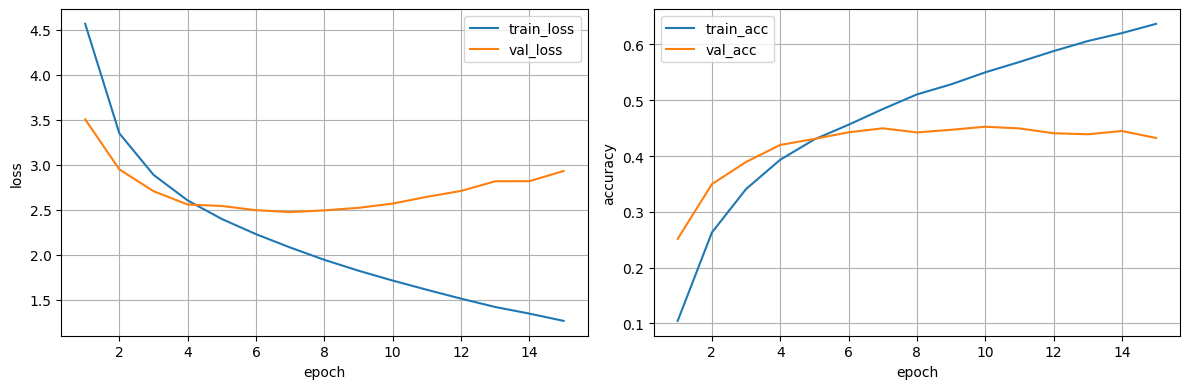

test_loss=2.5598 test_acc=0.4488


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train_acc")
axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer=None, train=False, device=device)
print(f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}")


Экспериментальный анализ
-----

В рамках работы было осуществлено сравнение трех вариантов моделей для классификации изображений QuickDraw: MLP на NumPy, MLP на PyTorch и сверточная нейронная сеть. Для MLP также был проведён эксперимент с функциями активации ReLU и Tanh, чтобы оценить влияние нелинейности на качество классификации. Наилучший результат среди полносвязных моделей показал NumPy MLP с ReLU: best val_acc = 0.3128, test_acc = 0.3078. Для PyTorch MLP с ReLU метрики оказались близкими: best val_acc = 0.3040, test_acc = 0.2935. Варианты с Tanh показали худшее качество, особенно в PyTorch-версии, где test_acc снизилась до 0.2708. Лучший результат продемонстрировала CNN: best val_acc = 0.4525, test_acc = 0.4488, что подтверждает преимущество свёрточной архитектуры для задач классификации изображений.

Сводная таблица
------

| Модель | Активация | Best epoch | Best val_acc | Test acc | Вывод |
|---|---:|---:|---:|---:|---|
| NumPy MLP | ReLU | 18 | 0.3128 | 0.3078 | Лучшая из MLP-реализаций на NumPy |
| NumPy MLP | Tanh | 18 | 0.3128 | 0.2827 | Хуже ReLU на тесте |
| TorchMLP | ReLU | 10 | 0.3040 | 0.2935 | Сопоставимо с NumPy, но немного ниже |
| TorchMLP | Tanh | 7 | 0.2735 | 0.2708 | Наихудший из MLP-вариантов |
| TorchCNN | ReLU | 10 | 0.4525 | 0.4488 | Лучший результат среди всех моделей |

Выводы:
-------

Эксперименты показали, что ReLU в среднем показывает лучшую эффективность на валидационных данных, чем Tanh, поскольку обеспечивает более стабильное обучение и меньше страдает от проблемы затухания градиентов. Сравнение NumPy и PyTorch-версий MLP показало близкие результаты, что подтверждает корректность реализации базовой архитектуры и процесса обучения. Существенный прирост качества был достигнут при переходе к CNN, так как свёрточная сеть лучше извлекает локальные пространственные признаки изображений. Основные численные трудности были связаны с переобучением и ошибками согласования размерностей, которые были устранены с помощью early stopping, корректной подготовки входных данных и сохранения лучшего состояния модели. Таким образом, для данной задачи наилучший баланс качества и устойчивости показала именно CNN-архитектура.

In [54]:
def predict_numpy(model, x):
    """
    x: np.ndarray shape (n_samples, n_features)
    return:
        pred: np.ndarray shape (n_samples,)
        prob: np.ndarray shape (n_samples, n_classes)
    """
    logits = model.forward(x, train=False)
    probs = model.softmax(logits)
    pred = np.argmax(probs, axis=1)
    conf = np.max(probs, axis=1)
    return pred, probs, conf

In [52]:
import numpy as np
import torch

def predict_torch(model, x, device="cpu"):
    """
    x: np.ndarray or torch.Tensor
    return:
        pred: np.ndarray shape (n_samples,)
        prob: np.ndarray shape (n_samples, n_classes)
        conf: np.ndarray shape (n_samples,)
    """
    model.eval()

    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x)

    x = x.to(device=device, dtype=torch.float32)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1)

    return pred.cpu().numpy(), probs.cpu().numpy(), probs.max(dim=1).values.cpu().numpy()

In [73]:
def predict_torch_cnn(model, x, device="cpu"):
    model.eval()

    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x)

    if x.ndim == 3 and x.shape[-1] == 1:
        x = x.permute(2, 0, 1).unsqueeze(0)   # HWC -> NCHW
    elif x.ndim == 3:
        x = x.unsqueeze(0).unsqueeze(0)       # HW -> NCHW
    elif x.ndim == 4 and x.shape[-1] == 1:
        x = x.permute(0, 3, 1, 2)             # NHWC -> NCHW

    x = x.to(device=device, dtype=torch.float32)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1)

    return pred.cpu().numpy(), probs.cpu().numpy(), probs.max(dim=1).values.cpu().numpy()

In [74]:
num_tests = 10
loaded_mlp_model = MLP.load("quickdraw_mlp.pkl")

print("MLP Evaluation (ReLU)")
for idx in range(num_tests):
    x = X_test_flat[idx:idx+1]  # сохраняем batch dimension
    pred, probs, conf = predict_numpy(loaded_mlp_model, x)

    pred = pred[0]
    conf = conf[0]
    true = y_test[idx]

    print(f"idx: {idx}, True: {true}, Pred: {pred}, Prob: {conf:.4f}, Correct: {pred == true}")

MLP Evaluation (ReLU)
idx: 0, True: 282, Pred: 282, Prob: 0.9913, Correct: True
idx: 1, True: 180, Pred: 112, Prob: 0.6246, Correct: False
idx: 2, True: 238, Pred: 130, Prob: 0.1245, Correct: False
idx: 3, True: 213, Pred: 96, Prob: 0.6189, Correct: False
idx: 4, True: 146, Pred: 131, Prob: 0.3555, Correct: False
idx: 5, True: 21, Pred: 21, Prob: 0.6270, Correct: True
idx: 6, True: 77, Pred: 272, Prob: 0.9223, Correct: False
idx: 7, True: 179, Pred: 231, Prob: 0.2784, Correct: False
idx: 8, True: 118, Pred: 118, Prob: 0.2274, Correct: True
idx: 9, True: 209, Pred: 209, Prob: 0.8938, Correct: True


In [75]:
print("Torch Evaluation (ReLU)")
checkpoint = torch.load("best_torchmlp.pt", map_location=device)

loaded_torch_model = TorchMLP().to(device)
loaded_torch_model.load_state_dict(checkpoint["model_state_dict"])
loaded_torch_model.eval()

for idx in range(num_tests):
    x = X_test[idx:idx+1]
    pred, probs, conf = predict_torch(loaded_torch_model, x, device=device)

    pred = pred[0]
    conf = conf[0]
    true = y_test[idx]

    print(f"idx: {idx}, True: {true}, Pred: {pred}, Prob: {conf:.4f}, Correct: {pred == true}")

Torch Evaluation (ReLU)
idx: 0, True: 282, Pred: 282, Prob: 0.9578, Correct: True
idx: 1, True: 180, Pred: 83, Prob: 0.2607, Correct: False
idx: 2, True: 238, Pred: 36, Prob: 0.0718, Correct: False
idx: 3, True: 213, Pred: 96, Prob: 0.6291, Correct: False
idx: 4, True: 146, Pred: 131, Prob: 0.2962, Correct: False
idx: 5, True: 21, Pred: 263, Prob: 0.4531, Correct: False
idx: 6, True: 77, Pred: 272, Prob: 0.3543, Correct: False
idx: 7, True: 179, Pred: 104, Prob: 0.6206, Correct: False
idx: 8, True: 118, Pred: 118, Prob: 0.1157, Correct: True
idx: 9, True: 209, Pred: 209, Prob: 0.3001, Correct: True


In [76]:
print("Torch Evaluation (CNN)")
checkpoint = torch.load("best_cnn.pt", map_location=device)

loaded_torch_cnn_model = TorchCNN(num_classes=len(class_names)).to(device)
loaded_torch_cnn_model.load_state_dict(checkpoint["model_state_dict"])
loaded_torch_cnn_model.eval()

for idx in range(num_tests):
    x = X_test[idx:idx+1]
    pred, probs, conf = predict_torch_cnn(loaded_torch_cnn_model, x, device=device)

    pred = pred[0]
    conf = conf[0]
    true = y_test[idx]

    print(f"idx: {idx}, True: {true}, Pred: {pred}, Prob: {conf:.4f}, Correct: {pred == true}")

Torch Evaluation (CNN)
idx: 0, True: 282, Pred: 282, Prob: 1.0000, Correct: True
idx: 1, True: 180, Pred: 175, Prob: 0.5701, Correct: False
idx: 2, True: 238, Pred: 238, Prob: 0.5893, Correct: True
idx: 3, True: 213, Pred: 213, Prob: 0.2452, Correct: True
idx: 4, True: 146, Pred: 131, Prob: 0.7907, Correct: False
idx: 5, True: 21, Pred: 21, Prob: 0.6449, Correct: True
idx: 6, True: 77, Pred: 77, Prob: 0.3520, Correct: True
idx: 7, True: 179, Pred: 231, Prob: 0.4342, Correct: False
idx: 8, True: 118, Pred: 118, Prob: 0.1877, Correct: True
idx: 9, True: 209, Pred: 209, Prob: 0.9715, Correct: True


In [78]:
import pandas as pd
import numpy as np
import torch

num_tests = 10
rows = []

# ===== NumPy MLP =====
loaded_mlp_model = MLP.load("quickdraw_mlp.pkl")

for idx in range(num_tests):
    x = X_test_flat[idx:idx+1]
    true = int(y_test[idx])

    pred, probs, conf = predict_numpy(loaded_mlp_model, x)
    pred = int(pred[0])
    conf = float(conf[0])

    rows.append({
        "idx": idx,
        "model": "NumPy MLP",
        "true": true,
        "pred": pred,
        "conf": conf,
        "correct": pred == true,
    })

# ===== Torch MLP =====
checkpoint = torch.load("best_torchmlp.pt", map_location=device)
loaded_torch_mlp_model = TorchMLP().to(device)
loaded_torch_mlp_model.load_state_dict(checkpoint["model_state_dict"])
loaded_torch_mlp_model.eval()

for idx in range(num_tests):
    x = X_test[idx:idx+1]
    true = int(y_test[idx])

    pred, probs, conf = predict_torch(loaded_torch_mlp_model, x, device=device)
    pred = int(pred[0])
    conf = float(conf[0])

    rows.append({
        "idx": idx,
        "model": "Torch MLP",
        "true": true,
        "pred": pred,
        "conf": conf,
        "correct": pred == true,
    })

# ===== Torch CNN =====
checkpoint = torch.load("best_cnn.pt", map_location=device)
loaded_torch_cnn_model = TorchCNN(num_classes=len(class_names)).to(device)
loaded_torch_cnn_model.load_state_dict(checkpoint["model_state_dict"])
loaded_torch_cnn_model.eval()

for idx in range(num_tests):
    x = X_test[idx:idx+1]
    true = int(y_test[idx])

    pred, probs, conf = predict_torch_cnn(loaded_torch_cnn_model, x, device=device)
    pred = int(pred[0])
    conf = float(conf[0])

    rows.append({
        "idx": idx,
        "model": "Torch CNN",
        "true": true,
        "pred": pred,
        "conf": conf,
        "correct": pred == true,
    })

df_preds = pd.DataFrame(rows)

print(df_preds.to_markdown(index=False))

|   idx | model     |   true |   pred |      conf | correct   |
|------:|:----------|-------:|-------:|----------:|:----------|
|     0 | NumPy MLP |    282 |    282 | 0.991298  | True      |
|     1 | NumPy MLP |    180 |    112 | 0.624632  | False     |
|     2 | NumPy MLP |    238 |    130 | 0.124452  | False     |
|     3 | NumPy MLP |    213 |     96 | 0.618893  | False     |
|     4 | NumPy MLP |    146 |    131 | 0.355483  | False     |
|     5 | NumPy MLP |     21 |     21 | 0.626985  | True      |
|     6 | NumPy MLP |     77 |    272 | 0.922284  | False     |
|     7 | NumPy MLP |    179 |    231 | 0.278432  | False     |
|     8 | NumPy MLP |    118 |    118 | 0.227356  | True      |
|     9 | NumPy MLP |    209 |    209 | 0.893792  | True      |
|     0 | Torch MLP |    282 |    282 | 0.957765  | True      |
|     1 | Torch MLP |    180 |     83 | 0.260736  | False     |
|     2 | Torch MLP |    238 |     36 | 0.0717742 | False     |
|     3 | Torch MLP |    213 |     96 | 

## Инференс и сравнение качества

| # | Модель | True | Pred | Conf | Correct |
|---:|---|---:|---:|---:|:---:|
| 0 | NumPy MLP | 282 | 282 | 0.9913 | ✅ |
| 1 | NumPy MLP | 180 | 112 | 0.6246 | ❌ |
| 2 | NumPy MLP | 238 | 130 | 0.1245 | ❌ |
| 3 | NumPy MLP | 213 | 96 | 0.6189 | ❌ |
| 4 | NumPy MLP | 146 | 131 | 0.3555 | ❌ |
| 5 | NumPy MLP | 21 | 21 | 0.6270 | ✅ |
| 6 | NumPy MLP | 77 | 272 | 0.9223 | ❌ |
| 7 | NumPy MLP | 179 | 231 | 0.2784 | ❌ |
| 8 | NumPy MLP | 118 | 118 | 0.2274 | ✅ |
| 9 | NumPy MLP | 209 | 209 | 0.8938 | ✅ |
| 0 | Torch MLP | 282 | 282 | 0.9578 | ✅ |
| 1 | Torch MLP | 180 | 83 | 0.2607 | ❌ |
| 2 | Torch MLP | 238 | 36 | 0.0718 | ❌ |
| 3 | Torch MLP | 213 | 96 | 0.6291 | ❌ |
| 4 | Torch MLP | 146 | 131 | 0.2962 | ❌ |
| 5 | Torch MLP | 21 | 263 | 0.4532 | ❌ |
| 6 | Torch MLP | 77 | 272 | 0.3543 | ❌ |
| 7 | Torch MLP | 179 | 104 | 0.6206 | ❌ |
| 8 | Torch MLP | 118 | 118 | 0.1157 | ✅ |
| 9 | Torch MLP | 209 | 209 | 0.3001 | ✅ |
| 0 | Torch CNN | 282 | 282 | 0.99997 | ✅ |
| 1 | Torch CNN | 180 | 175 | 0.5701 | ❌ |
| 2 | Torch CNN | 238 | 238 | 0.5893 | ✅ |
| 3 | Torch CNN | 213 | 213 | 0.2452 | ✅ |
| 4 | Torch CNN | 146 | 131 | 0.7907 | ❌ |
| 5 | Torch CNN | 21 | 21 | 0.6449 | ✅ |
| 6 | Torch CNN | 77 | 77 | 0.3520 | ✅ |
| 7 | Torch CNN | 179 | 231 | 0.4342 | ❌ |
| 8 | Torch CNN | 118 | 118 | 0.1877 | ✅ |
| 9 | Torch CNN | 209 | 209 | 0.9715 | ✅ |

## Инференс

| Модель | Correct / 10 | Краткий вывод |
|---|---:|---|
| NumPy MLP | 4 | Часто ошибается на похожих классах, иногда уверенно ошибается. |
| Torch MLP | 3 | Качество ниже NumPy MLP, ошибки на похожих объектах. |
| Torch CNN | 7 | Лучший результат: лучше распознаёт локальные признаки и чаще даёт верный ответ. |

**Вывод:** CNN показала наилучшее качество на примерах инференса. Полносвязные модели чаще ошибались на визуально похожих классах, что подтверждает преимущество сверточной архитектуры для задач классификации изображений.

Три шага для улучшения
----
1. Добавить data augmentation, чтобы модель видела больше вариантов одного и того же рисунка.
2. Усилить CNN: BatchNorm, дополнительный сверточный блок, dropout/weight decay.
3. Анализировать ошибки по классам и при необходимости использовать балансировку классов или больше данных для слабых классов.